In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("//home/tim/cluster/precompute/use-cases/thread-sanitizer/sample_apps/performance-eval//results_lulesh.csv")
# Extract size and iterations using regex
df['size'] = df['config'].str.extract(r'-s\s+(\d+)').astype(int)
df['iterations'] = df['config'].str.extract(r'-i\s+(\d+)').astype(int)
# time is in seconds: to float
df['time'] = df['time'].str.replace('s', '').astype(float)


In [11]:
df

,config,num_threads,mode,time,size,iterations
0,-s 20 -i 80,8,modified,16.09,20,80
1,-s 20 -i 80,8,normal,17.90,20,80
2,-s 20 -i 80,8,without,0.49,20,80
3,-s 40 -i 10,8,modified,12.40,40,10
4,-s 40 -i 10,8,normal,12.76,40,10
...,...,...,...,...,...,...
175,-s 20 -i 40,8,normal,9.19,20,40
176,-s 20 -i 40,8,without,0.25,20,40
177,-s 20 -i 60,8,modified,12.12,20,60
178,-s 20 -i 60,8,normal,14.65,20,60


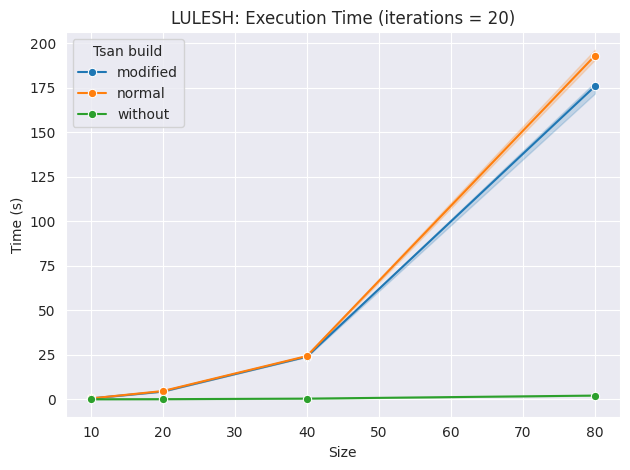

In [12]:
iter_val=20
df_filtered = df[df["iterations"] == iter_val]

# Create the line plot
sns.lineplot(data=df_filtered, x="size", y="time", hue="mode", marker="o")

plt.title(f"LULESH: Execution Time (iterations = {iter_val})")
plt.xlabel("Size")
plt.ylabel("Time (s)")
plt.legend(title="Tsan build")
plt.tight_layout()
plt.savefig("lulesh_time.pdf")

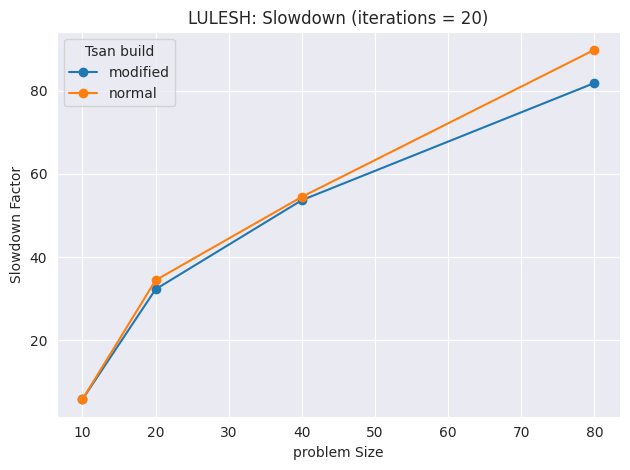

In [13]:
iter_val=20
df_filtered = df[df["iterations"] == iter_val]
mean_times = df_filtered.groupby(["iterations","size", "mode"])["time"].mean().reset_index()
# Pivot to wide format*: one row per config, columns per mode
pivoted = mean_times.pivot(index="size", columns="mode", values="time")
# Normalize all modes relative to 'without'
percentages = pivoted.div(pivoted["without"], axis=0)

percentages[["modified", "normal"]].plot(kind="line", marker="o")

plt.title(f"LULESH: Slowdown (iterations = {iter_val})")
plt.xlabel("problem Size")
plt.ylabel("Slowdown Factor")
plt.legend(title="Tsan build")
plt.tight_layout()
plt.savefig("lulesh_slowdown.pdf")

In [14]:
df_hpccg = pd.read_csv("/home/tim/cluster/precompute/use-cases/thread-sanitizer/sample_apps/performance-eval/results_hpccg.csv")
# Extract size and iterations using regex
df_hpccg['size'] = df_hpccg['config'].str.extract(r'(\d+)').astype(int)
# time is in seconds: to float
df_hpccg['time'] = df_hpccg['time'].str.replace('s', '').astype(float)

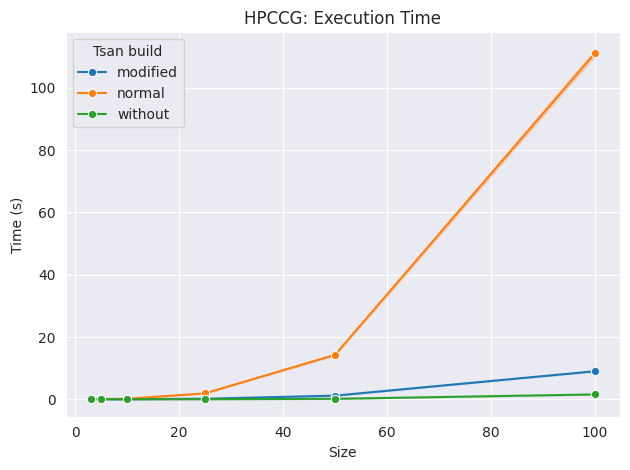

In [15]:
# Create the line plot
sns.lineplot(data=df_hpccg, x="size", y="time", hue="mode", marker="o")

plt.title(f"HPCCG: Execution Time")
plt.xlabel("Size")
plt.ylabel("Time (s)")
plt.legend(title="Tsan build")
plt.tight_layout()
plt.savefig("hpccg_time.pdf")

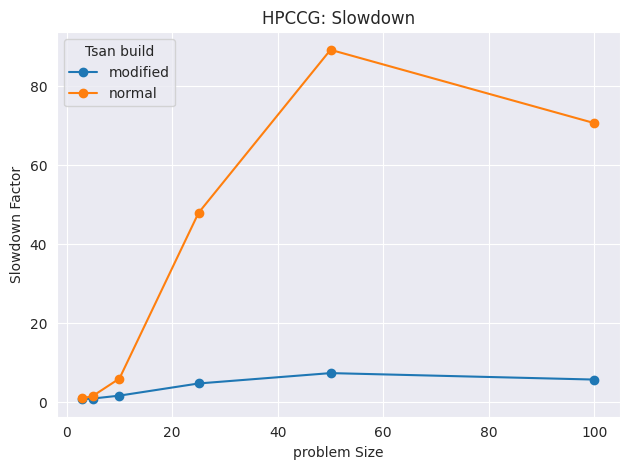

In [17]:
mean_times = df_hpccg.groupby(["size", "mode"])["time"].mean().reset_index()
# Pivot to wide format*: one row per config, columns per mode
pivoted = mean_times.pivot(index="size", columns="mode", values="time")
# Normalize all modes relative to 'without'
percentages = pivoted.div(pivoted["without"], axis=0)

percentages[["modified", "normal"]].plot(kind="line", marker="o")

plt.title(f"HPCCG: Slowdown")
plt.xlabel("problem Size")
plt.ylabel("Slowdown Factor")
plt.legend(title="Tsan build")
plt.tight_layout()
plt.savefig("hpccg_slowdown.pdf")

In [18]:
percentages

mode,modified,normal,without
size,,,
3,0.750000,0.950000,1.0
5,0.937500,1.625000,1.0
10,1.666667,6.000000,1.0
25,4.750000,48.000000,1.0
50,7.375000,89.291667,1.0
100,5.736730,70.711253,1.0


In [ ]:
ö